In [46]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [47]:
df = pd.read_csv('/Users/j.a.r.v.i.s./Documents/Home Credit Default Risk/application_train.csv')

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [49]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
df.isnull().mean()*100

SK_ID_CURR                     0.000000
TARGET                         0.000000
NAME_CONTRACT_TYPE             0.000000
CODE_GENDER                    0.000000
FLAG_OWN_CAR                   0.000000
                                ...    
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
Length: 122, dtype: float64

In [51]:
null_pct = df.isnull().mean() * 100
null_pct[null_pct > 30].sort_values(ascending=False)

COMMONAREA_AVG                  69.872297
COMMONAREA_MEDI                 69.872297
COMMONAREA_MODE                 69.872297
NONLIVINGAPARTMENTS_MEDI        69.432963
NONLIVINGAPARTMENTS_MODE        69.432963
NONLIVINGAPARTMENTS_AVG         69.432963
FONDKAPREMONT_MODE              68.386172
LIVINGAPARTMENTS_MEDI           68.354953
LIVINGAPARTMENTS_MODE           68.354953
LIVINGAPARTMENTS_AVG            68.354953
FLOORSMIN_MODE                  67.848630
FLOORSMIN_MEDI                  67.848630
FLOORSMIN_AVG                   67.848630
YEARS_BUILD_MODE                66.497784
YEARS_BUILD_AVG                 66.497784
YEARS_BUILD_MEDI                66.497784
OWN_CAR_AGE                     65.990810
LANDAREA_MEDI                   59.376738
LANDAREA_MODE                   59.376738
LANDAREA_AVG                    59.376738
BASEMENTAREA_MEDI               58.515956
BASEMENTAREA_AVG                58.515956
BASEMENTAREA_MODE               58.515956
EXT_SOURCE_1                    56

In [52]:
## Dropping the data which is above 40% null due to low relevance to the model

columns_to_drop = null_pct[null_pct > 40].index.to_list()
df.drop(columns = columns_to_drop,inplace = True)
df.shape

(307511, 73)

In [53]:
print(df['DAYS_EMPLOYED'].describe())
print(df['DAYS_EMPLOYED'].value_counts().head(10))

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64
DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-230         151
-199         151
-212         150
-384         143
-229         143
-231         140
-215         138
Name: count, dtype: int64


In [54]:
# For unemployed and Pensioner Applicants

print(df[df['DAYS_EMPLOYED'] > 0]['DAYS_EMPLOYED'].value_counts())

DAYS_EMPLOYED
365243    55374
Name: count, dtype: int64


In [55]:
# Just to mark these replacements differently from people who already have 0 DAYS_EMPLOYED

df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

In [56]:
df['DAYS_EMPLOYED'].isnull().sum()

55374

In [57]:
df.groupby('DAYS_EMPLOYED_ANOMALY')['TARGET'].mean()*100

DAYS_EMPLOYED_ANOMALY
0    8.659975
1    5.399646
Name: TARGET, dtype: float64

In [58]:
df[df['DAYS_EMPLOYED_ANOMALY'] == 1]['NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64

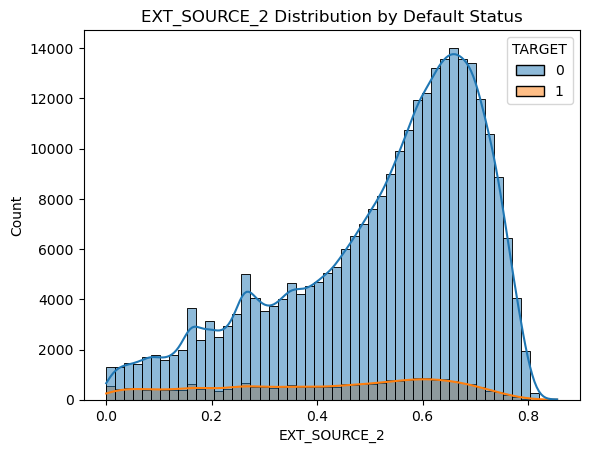

In [59]:
sns.histplot(data=df, x='EXT_SOURCE_2', hue='TARGET', bins=50, kde=True)
plt.title('EXT_SOURCE_2 Distribution by Default Status')
plt.savefig('ext_source2_dist.png',dpi = 150)
plt.show()

##### The distribution for non-defaulters is a Normal distribution skewed to the left. Whereas for the defaulters, it is evenly spread from 0 to 0.8 of EXT_SOURCE_2

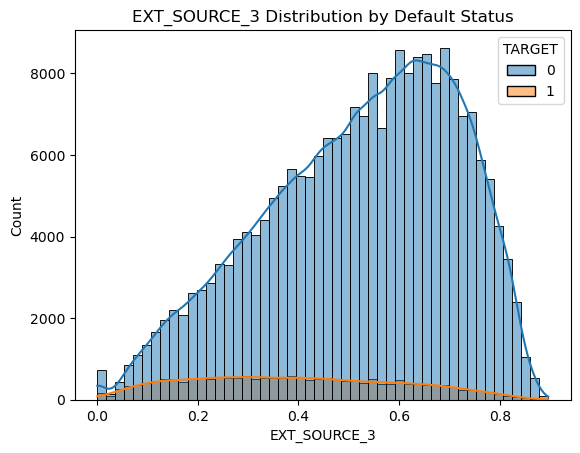

In [60]:
sns.histplot(data=df, x='EXT_SOURCE_3', hue='TARGET', bins=50, kde=True)
plt.title('EXT_SOURCE_3 Distribution by Default Status')
plt.savefig('ext_source3_dist.png',dpi = 150)
plt.show()


##### We have a similar result in this too.

In [61]:
ext_cols = ['EXT_SOURCE_2', 'EXT_SOURCE_3']

# Correlation check
print(df[ext_cols].corr())

              EXT_SOURCE_2  EXT_SOURCE_3
EXT_SOURCE_2      1.000000      0.109167
EXT_SOURCE_3      0.109167      1.000000


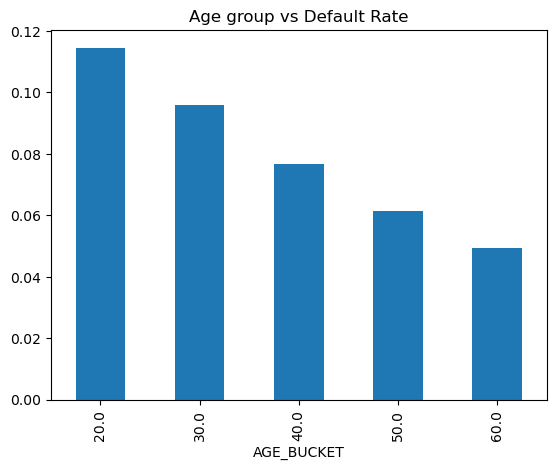

In [62]:
df['AGE_YEARS'] = df['DAYS_BIRTH'].abs()/365

df['AGE_BUCKET'] = (df['AGE_YEARS']//10)*10
df.groupby('AGE_BUCKET')['TARGET'].mean().plot(kind = 'bar')
plt.title('Age group vs Default Rate')
plt.savefig('age_default_rate.png', dpi = 150)
plt.show()

##### There is an almost linear trend of default rate decreasing with increase in age. 

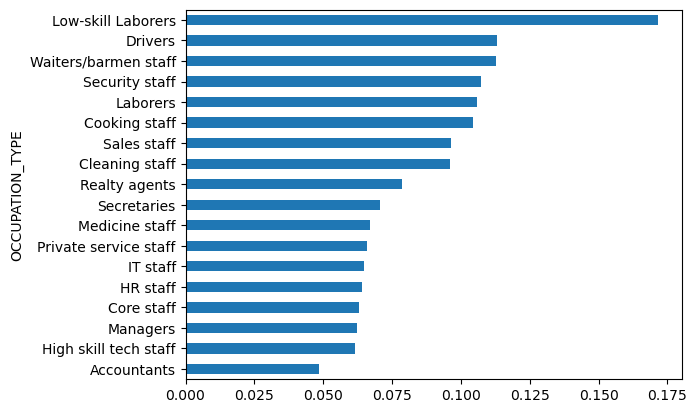

In [63]:
# sort_values() sorts the graph in descending order

df.groupby('OCCUPATION_TYPE')['TARGET'].mean().sort_values().plot(kind = 'barh')
plt.savefig('occupation_default.png',dpi = 150)
plt.show()

In [64]:
# agg is the aggregate function which runs multiple queries at a time and gives us the output in tabular form

df.groupby('OCCUPATION_TYPE')['TARGET'].agg(['mean','count']).sort_values('mean')

,mean,count
OCCUPATION_TYPE,,
Accountants,0.048303,9813
High skill tech staff,0.061599,11380
Managers,0.062140,21371
Core staff,0.063040,27570
HR staff,0.063943,563
IT staff,0.064639,526
Private service staff,0.065988,2652
Medicine staff,0.067002,8537
Secretaries,0.070498,1305


In [65]:
df['BURDEN'] = df['AMT_ANNUITY']/df['AMT_INCOME_TOTAL']

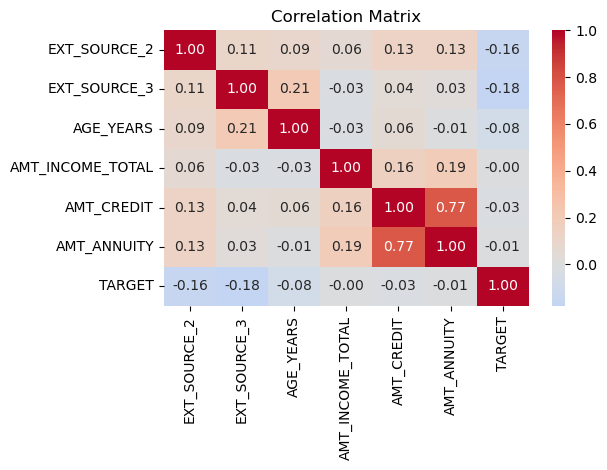

In [66]:
num_cols = ['EXT_SOURCE_2','EXT_SOURCE_3','AGE_YEARS',
            'AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','TARGET']

sns.heatmap(df[num_cols].corr(), annot= True, fmt = '.2f', cmap = 'coolwarm', center = 0) # '.2f' --> 2 is the number of digits and f represents float.
plt.title('Correlation Matrix')
plt.tight_layout() # Makes sure the labels are visible
plt.savefig('correlation_matrix.png', dpi = 150) # dpi is dots per inch which is the resolution of the image
plt.show()

##### The highest correlation is between the amount credit and amount annuity, which is quite obvious. Other than that, there are no significant relations between any two features. 

In [67]:
df['CREDIT_TERM'] = df['AMT_ANNUITY']/df['AMT_CREDIT']

## Would need to drop for the Linear Regression

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 78 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   307511 non-null  int64  
 1   TARGET                       307511 non-null  int64  
 2   NAME_CONTRACT_TYPE           307511 non-null  object 
 3   CODE_GENDER                  307511 non-null  object 
 4   FLAG_OWN_CAR                 307511 non-null  object 
 5   FLAG_OWN_REALTY              307511 non-null  object 
 6   CNT_CHILDREN                 307511 non-null  int64  
 7   AMT_INCOME_TOTAL             307511 non-null  float64
 8   AMT_CREDIT                   307511 non-null  float64
 9   AMT_ANNUITY                  307499 non-null  float64
 10  AMT_GOODS_PRICE              307233 non-null  float64
 11  NAME_TYPE_SUITE              306219 non-null  object 
 12  NAME_INCOME_TYPE             307511 non-null  object 
 13 

In [69]:
df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis = 1) 

In [70]:
df['EXT_SOURCE_AR_MEAN'] = (df['EXT_SOURCE_2']+df['EXT_SOURCE_3'])/2

In [71]:
print(df['EXT_SOURCE_MEAN'].isnull().sum())
print(df['EXT_SOURCE_AR_MEAN'].isnull().sum())

230
61395


##### The usual arithmetic mean returns NaN if either value is NaN.
##### .mean(axis=1) ignores NaN and returns the available value.
##### Impact on this dataset: naive method → 61,395 nulls; .mean(axis=1) → 230 nulls.
##### 61,165 rows (20% of data) retain their EXT_SOURCE signal because of this choice.

In [72]:
df.drop(columns = 'EXT_SOURCE_AR_MEAN',inplace = True)

In [73]:
df['CREDITxBURDEN'] = df['BURDEN'] * df['EXT_SOURCE_MEAN']
df['CREDITxAGE'] = df['AGE_YEARS'] * df['EXT_SOURCE_MEAN']
df['CREDITxINCOME'] = df['AMT_INCOME_TOTAL'] * df['EXT_SOURCE_MEAN']

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 82 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   307511 non-null  int64  
 1   TARGET                       307511 non-null  int64  
 2   NAME_CONTRACT_TYPE           307511 non-null  object 
 3   CODE_GENDER                  307511 non-null  object 
 4   FLAG_OWN_CAR                 307511 non-null  object 
 5   FLAG_OWN_REALTY              307511 non-null  object 
 6   CNT_CHILDREN                 307511 non-null  int64  
 7   AMT_INCOME_TOTAL             307511 non-null  float64
 8   AMT_CREDIT                   307511 non-null  float64
 9   AMT_ANNUITY                  307499 non-null  float64
 10  AMT_GOODS_PRICE              307233 non-null  float64
 11  NAME_TYPE_SUITE              306219 non-null  object 
 12  NAME_INCOME_TYPE             307511 non-null  object 
 13 

In [75]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)
print(f'Shape after one-hot encoding: {df.shape}')
print(f'New columns added: {df.shape[1] - 82}')

Shape after one-hot encoding: (307511, 182)
New columns added: 100


In [76]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']
cat_cols = df.select_dtypes(include = 'object').columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train = pd.get_dummies(X_train, columns=cat_cols, dummy_na=True)
X_test  = pd.get_dummies(X_test,  columns=cat_cols, dummy_na=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0) # Forces both of them to have same number of columns

In [77]:
weight = (y_train == 0).sum() / (y_train == 1).sum()
weight

11.38710976837865

In [78]:
from xgboost import XGBClassifier

model = XGBClassifier(
    scale_pos_weight=weight, ## This tells that a defaulter is weight* more important than a non-defaulter because of the skewness of the data
    eval_metric='auc',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [79]:
from sklearn.metrics import roc_auc_score

y_pred_prob = model.predict_proba(X_test)[:,1] 
auc = roc_auc_score(y_test,y_pred_prob)

print(f"AUC SCORE : {auc:.4f}") # The f on the outside looks for floating numbers and the inside one is to identify the number of digits after the decimal

# predict_proba returns an (n, 2) matrix: column 0 = P(safe), column 1 = P(default).
# [:, 1] slices out the default probabilities — one risk score per applicant.
# AUC needs probabilities (ranking), not 0/1 labels, so we pass these to roc_auc_score.
# Using X_test: the score that counts is on data the model never trained on.

AUC SCORE : 0.7629


In [80]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(15)

EXT_SOURCE_MEAN                                      0.160505
NAME_EDUCATION_TYPE_Higher education                 0.039343
CREDITxAGE                                           0.032323
CODE_GENDER_M                                        0.028526
NAME_EDUCATION_TYPE_Secondary / secondary special    0.024816
AMT_REQ_CREDIT_BUREAU_WEEK                           0.024365
FLAG_DOCUMENT_3                                      0.020242
NAME_CONTRACT_TYPE_Revolving loans                   0.018432
FLAG_OWN_CAR_Y                                       0.017537
DAYS_EMPLOYED                                        0.015821
CREDIT_TERM                                          0.015258
EXT_SOURCE_3                                         0.014903
NAME_FAMILY_STATUS_Married                           0.012569
REG_CITY_NOT_LIVE_CITY                               0.012460
AMT_GOODS_PRICE                                      0.011889
dtype: float32

##### We can confidently say that EXT_SOURCE_MEAN dominates the effect on TARGET values. But not so large that it becomes a one-feature-model. But the gap between #1 and #2 is huge.
##### But this is okay, because external credit scores are often the strongest signals in a credit risk prediction. 

In [81]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
print(f"CV AUC: {scores.mean():.4f} ± {scores.std():.4f}")

CV AUC: 0.7566 ± 0.0054


##### This shows that the single fold train test split landed almost where the 5-fold cross validation split did, so the model is not fragile and is reliable.